# Forecast clase A: ETS vs media móvil

La media móvil 30 días es el baseline de todo el catálogo. En el **top 100 clase A** (más ventas, series más regulares) se prueba Holt-Winters: nivel, tendencia amortiguada y estacionalidad semanal.

1. Mismo holdout de 30 días que la notebook 02
2. MAE por SKU y agregado (MA30 vs ETS)
3. Un SKU en detalle, día a día

`predict` usa ETS en los SKUs donde el modelo ajusta; el resto del catálogo sigue en media móvil.

> Requiere el paquete instalado en modo editable: `pip install -e .` desde la raíz del repo.


In [1]:
import pandas as pd

from inventario_ecommerce import config
from inventario_ecommerce.dataset import load_transactions, save_processed
from inventario_ecommerce.features import (
    clean_transactions,
    compute_abc_classification,
    prepare_daily_demand,
    sales_by_product_last_quarter,
)
from inventario_ecommerce.modeling.ets import (
    sku_backtest_series,
    temporal_backtest_ets_vs_baseline,
)
from inventario_ecommerce.plots import plot_class_a_mae_comparison, plot_sku_forecast_comparison

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Top-N clase A:", config.CLASS_A_ETS_TOP_N)
print("Estacionalidad ETS:", config.ETS_SEASONAL_PERIODS, "días")
print("Mínimo de historia para ajustar:", config.ETS_MIN_TRAIN_DAYS, "días")


Top-N clase A: 100
Estacionalidad ETS: 7 días
Mínimo de historia para ajustar: 56 días


## 1. Datos

Misma higiene de demanda que el resto del pipeline (`prepare_daily_demand`).


In [2]:
raw = load_transactions()
clean = clean_transactions(raw)
abc = compute_abc_classification(sales_by_product_last_quarter(clean))
daily = prepare_daily_demand(clean, abc=abc)

print(f"SKUs clase A (trimestre): {(abc['ABCClass'] == 'A').sum():,}")
print(f"Días-SKU calendario: {len(daily):,}")


SKUs clase A (trimestre): 684
Días-SKU calendario: 3,322,199


## 2. Backtest MA30 vs ETS

Holt-Winters aditivo, tendencia amortiguada, periodo 7. Si el ajuste falla o hay menos de 56 días de historia, ese SKU se queda con la media móvil.


In [3]:
by_sku, global_metrics = temporal_backtest_ets_vs_baseline(daily, abc)
global_metrics


ETS backtest 25/100


ETS backtest 50/100


ETS backtest 75/100


ETS backtest 100/100


,CutoffDate,EvalStartDate,EvalEndDate,SKUsEval,SKUsETSFit,SKUsETSBetter,GlobalMAE_ma30,GlobalMAE_ets,HorizonDays,LookbackDays,TopN
0,2011-11-09,2011-11-10,2011-12-09,99,95,69,40.47,37.04,30,30,100


In [4]:
row = global_metrics.iloc[0]
demanda_media = by_sku["RealMeanDaily"].mean()

print(f"SKUs evaluados: {int(row['SKUsEval'])} (ETS ajustó en {int(row['SKUsETSFit'])})")
print(f"Demanda media del grupo: {demanda_media:,.1f} ud/día")
print(f"MAE media móvil: {row['GlobalMAE_ma30']:.2f} ud/día")
print(f"MAE ETS:         {row['GlobalMAE_ets']:.2f} ud/día")
print(f"ETS mejora en {int(row['SKUsETSBetter'])} de {int(row['SKUsEval'])} SKUs")


SKUs evaluados: 99 (ETS ajustó en 95)
Demanda media del grupo: 53.0 ud/día
MAE media móvil: 40.47 ud/día
MAE ETS:         37.04 ud/día
ETS mejora en 69 de 99 SKUs


`MAE_delta` es cuánto baja el error al pasar de media móvil a ETS: positivo = ETS mejor. Ordenado de mayor a menor mejora.


In [5]:
ranking_cols = [
    config.COL_STOCK_CODE,
    config.COL_DESCRIPTION,
    "RealMeanDaily",
    "MAE_ma30",
    "MAE_ets",
    "MAE_delta",
    "ets_used",
]
by_sku.sort_values("MAE_delta", ascending=False)[ranking_cols].head(15)


,StockCode,Description,RealMeanDaily,MAE_ma30,MAE_ets,MAE_delta,ets_used
0,23084,RABBIT NIGHT LIGHT,239.70,146.62,73.36,73.26,ets
1,22086,PAPER CHAIN KIT 50'S CHRISTMAS,207.47,126.41,74.51,51.90,ets
4,22197,POPCORN HOLDER,227.73,128.09,94.71,33.37,ets
3,85099B,JUMBO BAG RED RETROSPOT,122.60,89.61,66.96,22.65,ets
7,22910,PAPER CHAIN KIT VINTAGE CHRISTMAS,121.27,82.86,61.68,21.18,ets
50,22355,CHARLOTTE BAG SUKI DESIGN,95.80,80.93,65.18,15.75,ets
6,85123A,WHITE HANGING HEART T-LIGHT HOLDER,119.90,88.46,73.45,15.01,ets
13,23203,JUMBO BAG VINTAGE DOILY,87.17,63.42,49.00,14.42,ets
38,23301,GARDENERS KNEELING PAD KEEP CALM,83.17,52.93,41.53,11.40,ets
39,22178,VICTORIAN GLASS HANGING T-LIGHT,79.90,62.75,51.44,11.31,ets


## 3. Un SKU en detalle

El SKU con más demanda en el holdout. La media móvil es una recta (un único valor para los 30 días); ETS sigue el nivel y el patrón semanal.


SKU 23084 — RABBIT NIGHT LIGHT
MAE media móvil: 146.62 ud/día
MAE ETS:         73.36 ud/día


WindowsPath('C:/code/proyecto-a-inventario-ecommerce/reports/figures/class_a_sku_forecast.png')

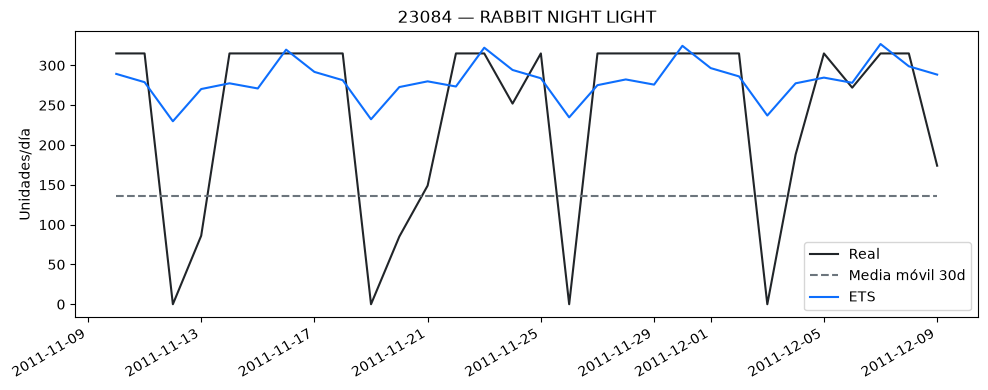

In [6]:
top_sku = str(by_sku.sort_values("RealMeanDaily", ascending=False).iloc[0][config.COL_STOCK_CODE])
comparison = sku_backtest_series(daily, top_sku)

print(f"SKU {top_sku} — {comparison.attrs['description']}")
print(f"MAE media móvil: {comparison.attrs['mae_ma30']:.2f} ud/día")
print(f"MAE ETS:         {comparison.attrs['mae_ets']:.2f} ud/día")

plot_sku_forecast_comparison(
    comparison,
    f"{top_sku} — {comparison.attrs['description']}",
    save=True,
)


## 4. Artefactos


WindowsPath('C:/code/proyecto-a-inventario-ecommerce/reports/figures/class_a_ets_vs_baseline.png')

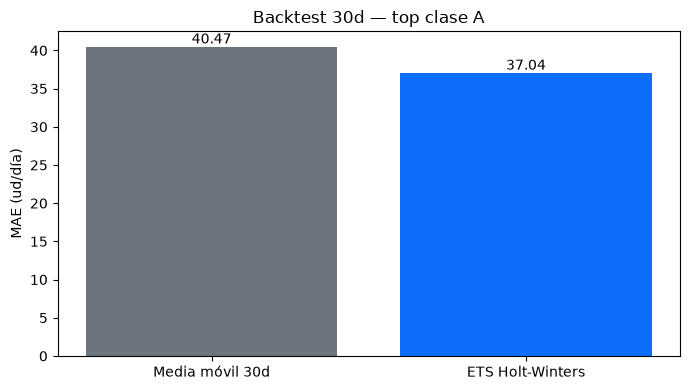

In [7]:
save_processed(by_sku, "forecast_backtest_class_a.csv")
save_processed(global_metrics, "forecast_backtest_class_a_global.csv")
plot_class_a_mae_comparison(global_metrics, save=True)


ETS reduce el error agregado del grupo, pero no gana en todos los SKUs: en series muy irregulares la media móvil aguanta mejor. Por eso `predict` solo lo aplica al top clase A, donde hay volumen e historia suficientes, y deja el resto del catálogo en el baseline.
